# Multivariate Analysis
Multivariate Analysis is the process of analyzing relationships among multiple variables simultaneously to identify patterns, correlations, interactions, and dependencies.

## Correlation Matrix


In [4]:
import pandas as pd
df = pd.read_csv("house_price_prediction_cleaned.csv")

In [8]:
df.columns

Index(['House_ ID', 'Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_years',
       'Location_Score', 'Parking_Spaces', 'Price_lakhs', 'Property_Type',
       'Furnishing_Status', 'Construction_Status', 'Locality_Type'],
      dtype='object')

In [12]:
numeric_columns = ["Area_sqft", "Bedrooms", "Bathrooms", "Age_years", "Location_Score", "Parking_Spaces", "Price_lakhs"]

In [13]:
numeric_df = df[numeric_columns]

numeric_df.head()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Location_Score,Parking_Spaces,Price_lakhs
0,850.0,4.0,1.0,20.5,5.0,1.0,42.0
1,900.0,2.0,1.0,18.0,5.0,2.0,45.0
2,2150.0,2.0,1.0,15.0,6.0,1.0,48.0
3,1000.9,2.0,2.0,12.0,6.0,1.0,52.0
4,1050.0,2.0,2.0,10.0,6.0,1.0,55.0


In [14]:
correlation_matrix = numeric_df.corr()

correlation_matrix

,Area_sqft,Bedrooms,Bathrooms,Age_years,Location_Score,Parking_Spaces,Price_lakhs
Area_sqft,1.000000,0.784635,0.843954,-0.390025,0.685594,0.715597,0.917623
Bedrooms,0.784635,1.000000,0.724496,-0.317075,0.598025,0.585075,0.801792
Bathrooms,0.843954,0.724496,1.000000,-0.626367,0.787190,0.750004,0.825550
Age_years,-0.390025,-0.317075,-0.626367,1.000000,-0.853320,-0.469686,-0.459933
Location_Score,0.685594,0.598025,0.787190,-0.853320,1.000000,0.625343,0.698695
Parking_Spaces,0.715597,0.585075,0.750004,-0.469686,0.625343,1.000000,0.735845
Price_lakhs,0.917623,0.801792,0.825550,-0.459933,0.698695,0.735845,1.000000


## 3. Heatmap


### Step 1 – Understand the Concept
Own Words; A Heatmap visually represents the correlation matrix.

It makes it easier to identify strong and weak relationships quickly.

### Step 2 – Real-World Analogy

Instead of reading:

Area       Price       0.95
    
Bedrooms   Price       0.80
    
the heatmap allows you to visually identify which relationships are strong or weak.

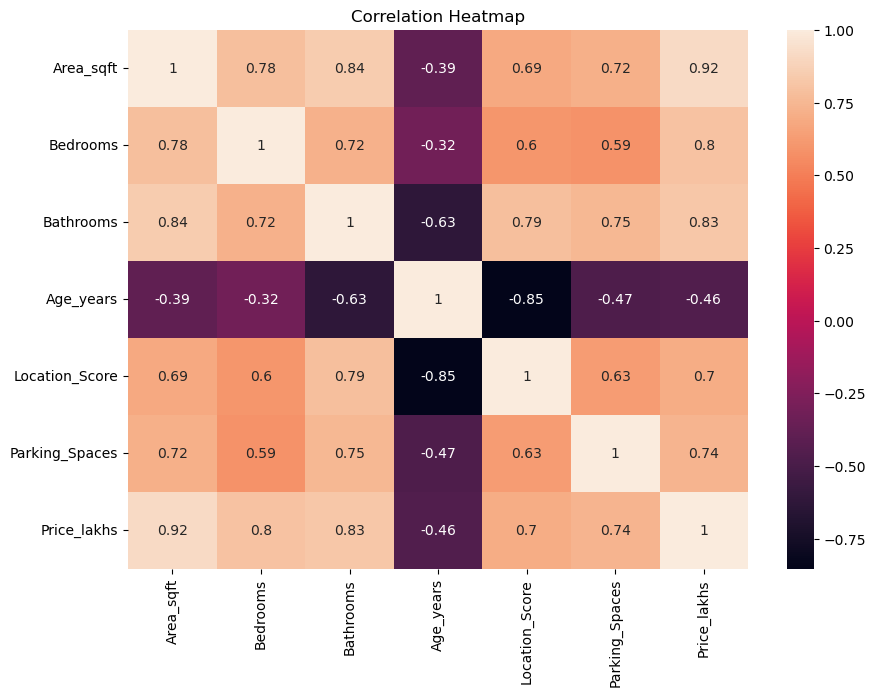

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
)

plt.title("Correlation Heatmap")

plt.show()

## 4. Pair Plot


In [ ]:
### Step 1 – Understand the Concept
Own Words: A Pair Plot creates multiple plots to show relationships between several numerical variables.

It provides:

Scatter plots between variables
Distribution of individual variables
Overall relationship patterns
### Step 2 – Real-World Analogy

Instead of separately creating: Area vs Price
Bedrooms vs Price
Bathrooms vs Price
Age vs Price

a pair plot gives you many of these relationships together.

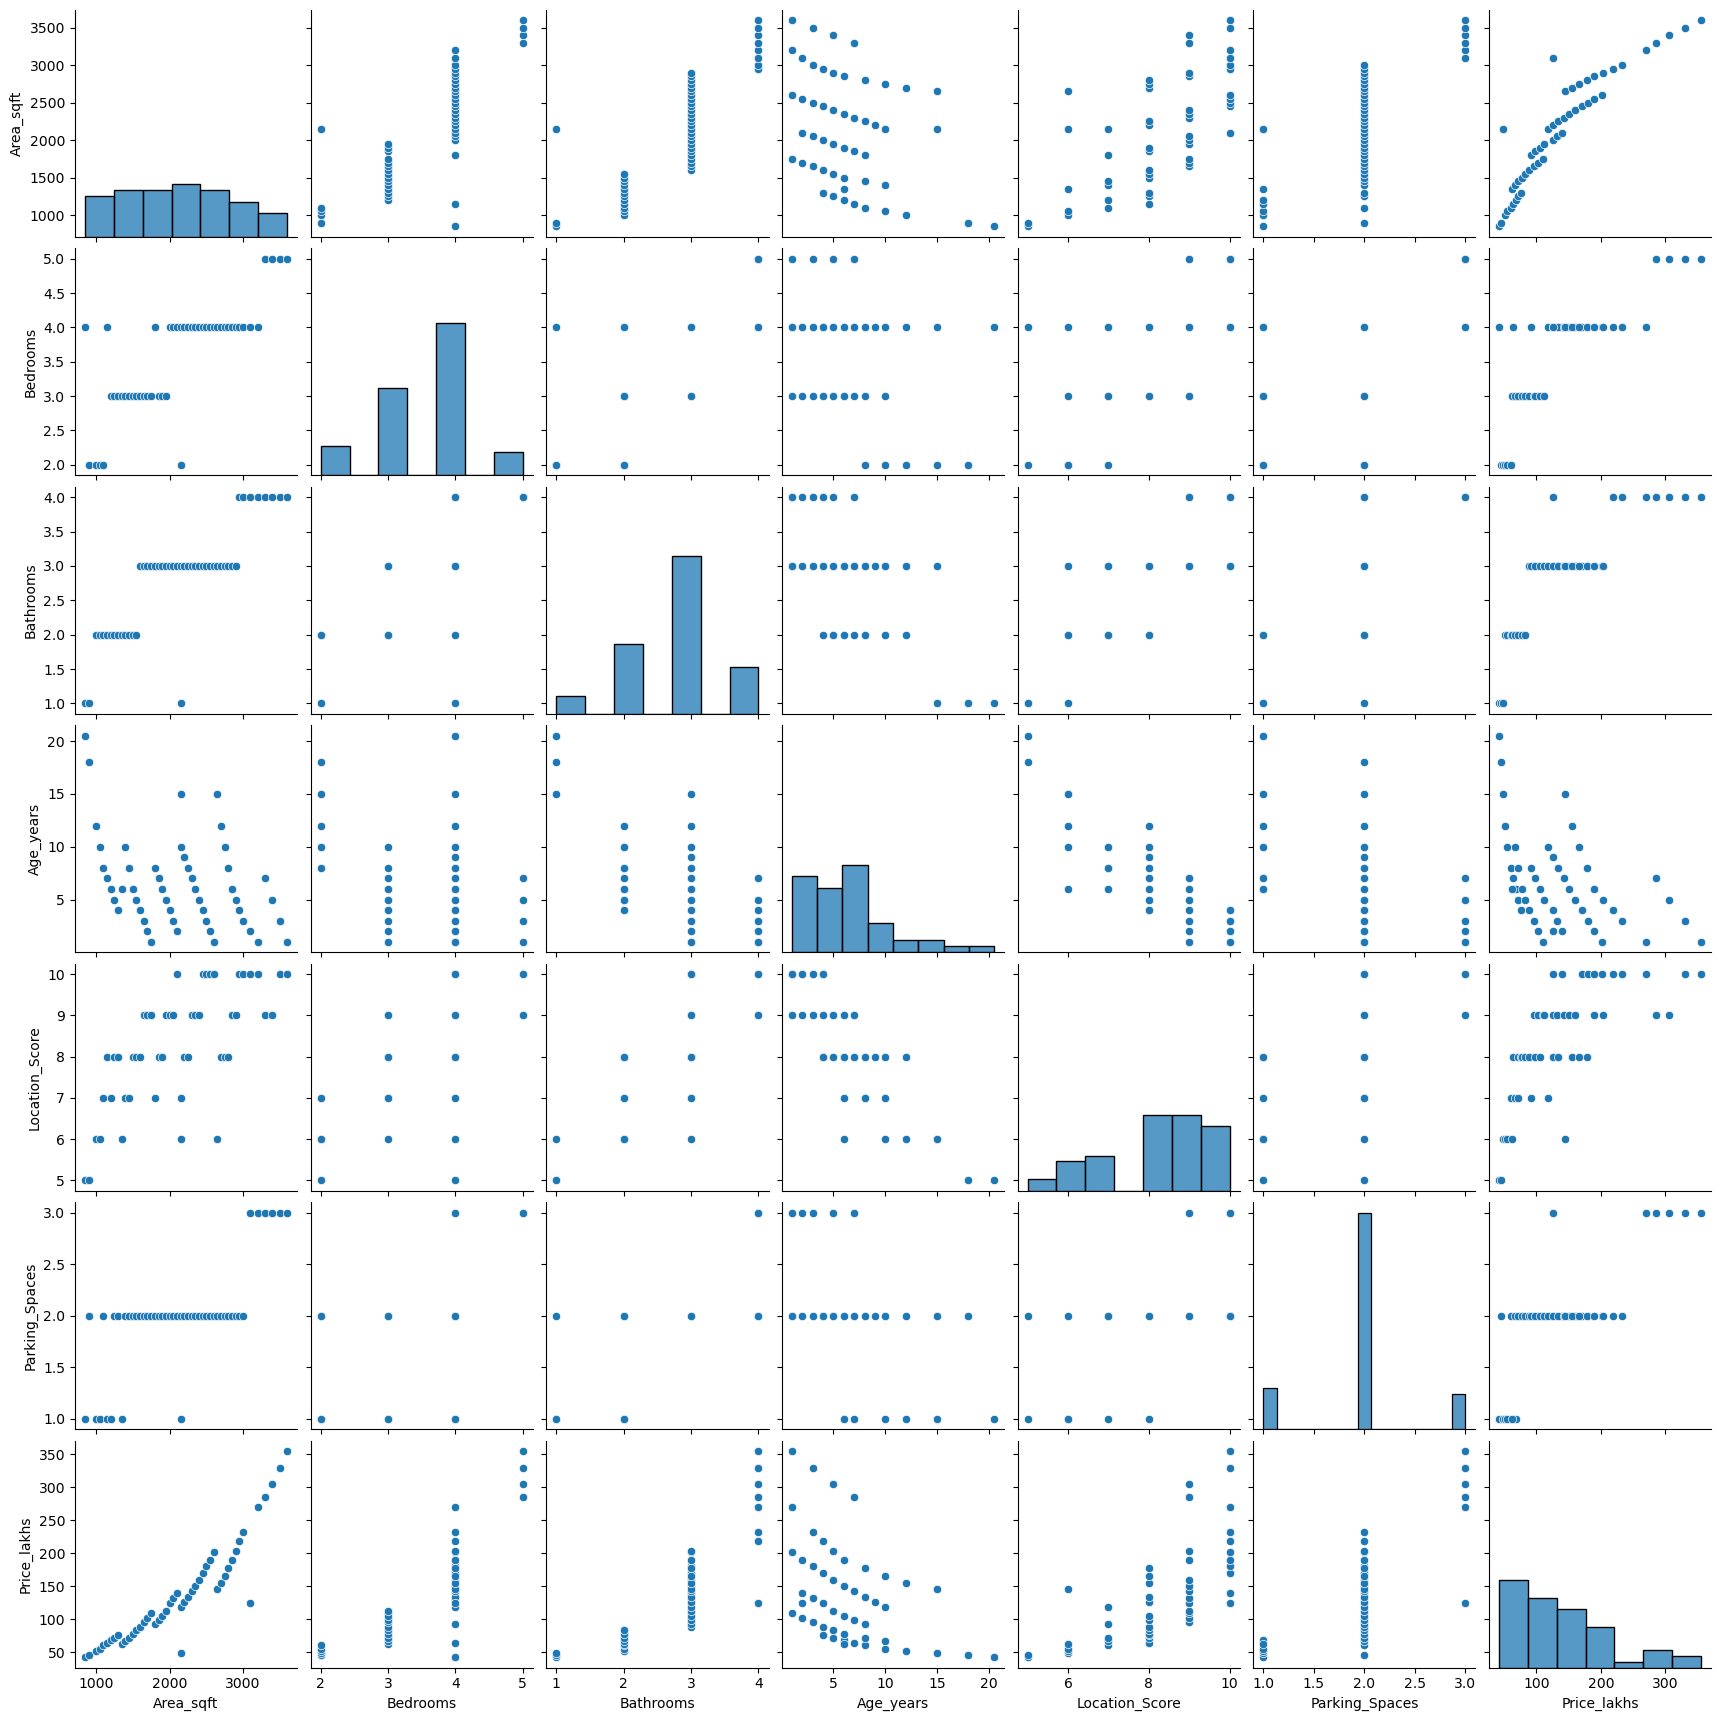

In [36]:
sns.pairplot(numeric_df)

plt.show()

### Multiple Feature Relationships


#### Step 1 – Understand the Concept
Own Words; Multiple Feature Relationships means examining how several features relate to the target variable and to one another.

For your house price project: Area_sqft,Bedrooms, Bathrooms,Age_years,Location_Score
Parking_Spaces
        ↓
Price_lakhs
#### Step 2 – Real-World Analogy

A house's price usually isn't determined by only one factor.

For example:

Large Area
   +
More Bedrooms
   +
More Bathrooms
   +
Good Location
   ↓
Higher House Price

This is a multiple-feature relationship.

#### Step 3 – Implement

First calculate correlations with the target:

In [42]:
price_correlations = (numeric_df.corr()["Price_lakhs"].sort_values(ascending=False))

price_correlations

Price_lakhs       1.000000
Area_sqft         0.917623
Bathrooms         0.825550
Bedrooms          0.801792
Parking_Spaces    0.735845
Location_Score    0.698695
Age_years        -0.459933
Name: Price_lakhs, dtype: float64

## Feature Interactions


### Step 1 – Understand the Concept
Own Words;A Feature Interaction occurs when the effect or meaning of one feature depends on another feature.

For example: Area_sqft + Bedrooms

together may provide more information about house price than considering either feature alone.

### Step 2 – Real-World Analogy

Consider:
House A:
Area = 2000 sqft
Bedrooms = 2

House B:
Area = 2000 sqft
Bedrooms = 4

Both have the same area, but their prices may differ because the number of bedrooms is different.

So:

Area + Bedrooms

can provide additional information.

### Step 3 – Implement

Create an interaction feature:

In [43]:
df["Area_Bedroom_Interaction"] = (
    df["Area_sqft"] * df["Bedrooms"]
)

In [44]:
df[
    [
        "Area_sqft",
        "Bedrooms",
        "Area_Bedroom_Interaction",
        "Price_lakhs"
    ]
].head()

,Area_sqft,Bedrooms,Area_Bedroom_Interaction,Price_lakhs
0,850.0,4.0,3400.0,42.0
1,900.0,2.0,1800.0,45.0
2,2150.0,2.0,4300.0,48.0
3,1000.9,2.0,2001.8,52.0
4,1050.0,2.0,2100.0,55.0


In [45]:
##  Numerical Feature Relationships


### Step 1 – Understand the Concept

Numerical feature relationships examine how numerical variables move together.

Your numerical features:

Area_sqft
Bedrooms
Bathrooms
Age_years
Location_Score
Parking_Spaces
Price_lakhs
### Step 2 – Real-World Analogy

Examples:

Area_sqft ↔ Bedrooms
Area_sqft ↔ Bathrooms
Bedrooms ↔ Bathrooms
Area_sqft ↔ Price_lakhs
Age_years ↔ Price_lakhs
Location_Score ↔ Price_lakhs
### Step 3 – Implement
feature_relationships = numeric_df.corr()

feature_relationships

In [46]:
feature_relationships = numeric_df.corr()

feature_relationships

,Area_sqft,Bedrooms,Bathrooms,Age_years,Location_Score,Parking_Spaces,Price_lakhs
Area_sqft,1.000000,0.784635,0.843954,-0.390025,0.685594,0.715597,0.917623
Bedrooms,0.784635,1.000000,0.724496,-0.317075,0.598025,0.585075,0.801792
Bathrooms,0.843954,0.724496,1.000000,-0.626367,0.787190,0.750004,0.825550
Age_years,-0.390025,-0.317075,-0.626367,1.000000,-0.853320,-0.469686,-0.459933
Location_Score,0.685594,0.598025,0.787190,-0.853320,1.000000,0.625343,0.698695
Parking_Spaces,0.715597,0.585075,0.750004,-0.469686,0.625343,1.000000,0.735845
Price_lakhs,0.917623,0.801792,0.825550,-0.459933,0.698695,0.735845,1.000000


In [48]:
df["Area_sqft"].corr(
    df["Price_lakhs"]
)

np.float64(0.9176234285501429)